# Recreating Original Moisture and Density Calculations #
Author(s): Maddox Chastain, Brandon Dugan

Summer 2026

## 1. Introduction ##

This notebook has the purpose of recreating the calculations seen within the original MAD (moisture and density) spreadsheets for all study sites of IODP EXP501. By recreating these original calculations, I hope to be able to easily adjust them to the varied levels of salinity seen at each site.

### 1.1 Notes (will remove/edit later) ###

- when correcting for varied salinity, keep an eye out for any equations using the standard lab values for pore-water salinity (s = 0.035 = 35/1000) and pore-water density (rho_pw = 1.024). These are the values we will have to focus on correcting using the soon-to-be-developed interpolated salinity model!!!

- also need to watch for usage of the calculated average seawater salt density value, rho_salt = 2.20 g/cm^3 (Lyman and Fleming, 1940; Weast et al., 1985)
    - while the paper I was given says that the most common density of salt used for MAD is 2.20 g/cm^3, the excel sheets show a used value of 2.22 g/cm^3, so I used that instead in the calculations below! 
    - according to the paper, "the average density of the standard seawater salt is between 2.10 and 2.24 g/cm^3." (section 2, page 4. PP Handbook, Peter Blum, November 1997.), so this variation in salt density isn't anything super out of the ordinary. 

- volume/weight grains = volume/weight solids when referencing PP Handbook (I think)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

## 2. Recreation ##

### 2.1 Reading in Data and Beaker Volumes ###

To recreate the original MAD calculations done for each site, I'll read in the first 20 columns of data from the combined MAD spreadsheet using Pandas. After reading in this initial data, I'll recreate the original calculations using the provided equations. Pandas allows for simple creation of new columns based upon arithmetic manipulations of existing columns, so this process is somewhat simple.

However, the volumes of the beaker used for each sample were not included in the original datasheets. Instead, these sheets were designed to reference a seperate sheet to obtain the values for beaker volumes. So, I'll read in the data from that referenced sheet and use it to create a new column for beaker volumes depending on which beaker was used for each sample!

In [2]:
df = pd.read_csv('/mnt/c/Users/maddo/onedrive/Desktop/Work stuff/SURF 2026/MAD-FF-Corrections-from-Varied-Salinity/spreadsheets/03_MAD/COMBINED_MAD/MAD_DATA_CSV.csv')

In [3]:
bkrs_df = pd.read_csv('/mnt/c/Users/maddo/onedrive/Desktop/Work stuff/SURF 2026/MAD-FF-Corrections-from-Varied-Salinity/spreadsheets/03_MAD/COMBINED_MAD/beakers_CSV.csv')#, index_col = 'Number')

In [4]:
for row in range(0, 600):
    num = df.iat[row, 12]
    for line in range(0, 137):
        if bkrs_df.iat[line, 0] == num:
            value = bkrs_df.iat[line, 2]
            df.at[row, 'Beaker Volume, cc'] = value
        else:
            continue

In [5]:
# checking initial data frame
df.head(n=2)

,Exp,Site,Hole,Core,Type,Section,"Sample Top, cm","Sample Bottom, cm",Combined id,Sample Label,...,"Sample Bot Depth, mbsf",Beaker Number,"Beaker Weight, g","WET Weight (Sample + Beaker), g",OVEN Date/Time IN,"DRY Weight (Sample + Beaker), g",Scientist,Pycnometer Cell,"DRY Volume, cc","Beaker Volume, cc"
0,501,M0111,A,1,H,1,63.5,65.5,M0111-A-1-1,"501-M0111A-1H-1,63.5-65.5",...,0.655,280,10.0747,19.1952,1/16/2026 11:00,17.7360,Shintani,1,7.39638,4.5178
1,501,M0111,A,2,H,2,38.0,40.0,M0111-A-2-2,"501-M0111A-2H-2,38-40",...,4.310,281,9.8647,19.8181,1/16/2026 11:00,17.8746,Shintani,2,7.44070,4.4236


### 2.2 Weight and Volume Calculations ###

In [6]:
full_wet_weight = df['WET Weight (Sample + Beaker), g ']
full_dry_weight = df['DRY Weight (Sample + Beaker), g']
beaker_weight = df['Beaker Weight,         g']


# WEIGHT WET Sample, g (full wet weight - beaker weight)
df['WEIGHT WET Sample, g'] = full_wet_weight - beaker_weight
wet_weight = df['WEIGHT WET Sample, g']

# WEIGHT DRY Sample, g (full dry weight - breaker weight)
df['WEIGHT DRY Sample, g'] = full_dry_weight - beaker_weight
dry_weight = df['WEIGHT DRY Sample, g']

# WEIGHT Pore Water, g ( (wet weight - dry weight)/(1-s), where s = 35/1000 or 0.035 )
df['WEIGHT Pore Water, g'] = (wet_weight - dry_weight)/(1-35/1000)

# WEIGHT Salt, g (weight pore water - (wet weight - dry weight))
df['WEIGHT Salt, g'] = (df['WEIGHT Pore Water, g']) - (wet_weight - dry_weight)

# WEIGHT Grains, g (weight dry - weight salt) <- this is how it's done in the spreadsheets
# This one keeps giving me problems, so I went with an eqn from the handbook instead (found in section 2 on page 13)
# Still giving me problems tho :(
df['WEIGHT Grains, g'] = (dry_weight - 0.035*wet_weight)/(1-0.035)


In [7]:
pw_weight = df['WEIGHT Pore Water, g']
salt_weight = df['WEIGHT Salt, g']
dry_volume = df['DRY Volume, cc']
beaker_volume = df['Beaker Volume, cc']

rho_pw = 1.024
rho_salt = 2.22


# VOLUME Pore Water, cc (pore water weight / pore water density) 
df['VOLUME Pore Water, cc'] = pw_weight / rho_pw

# VOLUME Salt, cc (weight salt / density salt)
df['VOLUME Salt, cc'] = salt_weight / rho_salt

# VOLUME Dry Sample, cc (dry volume - beaker volume)
df['VOLUME Dry Sample, cc'] = dry_volume - beaker_volume

# VOLUME Wet Sample, cc (dry sample volume - salt volume + pore water volume)
sample_dry_volume = df['VOLUME Dry Sample, cc']
salt_volume = df['VOLUME Salt, cc']
pw_volume = df['VOLUME Pore Water, cc']

df['VOLUME Wet Sample, cc'] = sample_dry_volume - salt_volume + pw_volume

# VOLUME Grains, cc (dry sample volume - salt volume)
df['VOLUME Grains, cc'] = sample_dry_volume - salt_volume


In [8]:
# checking progress made in data frame
df.head(n=2)

,Exp,Site,Hole,Core,Type,Section,"Sample Top, cm","Sample Bottom, cm",Combined id,Sample Label,...,"WEIGHT WET Sample, g","WEIGHT DRY Sample, g","WEIGHT Pore Water, g","WEIGHT Salt, g","WEIGHT Grains, g","VOLUME Pore Water, cc","VOLUME Salt, cc","VOLUME Dry Sample, cc","VOLUME Wet Sample, cc","VOLUME Grains, cc"
0,501,M0111,A,1,H,1,63.5,65.5,M0111-A-1-1,"501-M0111A-1H-1,63.5-65.5",...,9.1205,7.6613,1.512124,0.052924,7.608376,1.476684,0.023840,2.87858,4.331424,2.854740
1,501,M0111,A,2,H,2,38.0,40.0,M0111-A-2-2,"501-M0111A-2H-2,38-40",...,9.9534,8.0099,2.013990,0.070490,7.939410,1.966787,0.031752,3.01710,4.952135,2.985348


### 2.3 Water Content, Density, Porosity, and Void Ratio Calculations ###

In [9]:
grain_weight = df['WEIGHT Grains, g']


# Water Content, (wet) v/v (weight pore water / weight wet sample)
df['Water Content, (wet) v/v'] = pw_weight / wet_weight

# Water Content, (dry) v/v (weight pore water / weight grains)
df['Water Content, (dry) v/v'] = pw_weight / grain_weight


In [10]:
sample_wet_volume = df['VOLUME Wet Sample, cc']
grain_weight = df['WEIGHT Grains, g']
grain_volume = df['VOLUME Grains, cc']


# Bulk Density, g/cc (weight wet sample / volume wet sample)
df['Bulk Density, g/cc'] = wet_weight / sample_wet_volume

# Dry Density, g/cc (weight salt / volume wet sample) <- eqn used in spreadsheets
# (weight grains / volume wet sample) <- eqn used in handbook
df['Dry Density, g/cc'] = grain_weight / sample_wet_volume

# Grain Density, g/cc (weight grains / volume grains)
df['Grain Density, g/cc'] = grain_weight / grain_volume


In [11]:


# Porosity, v/v (volume pore water / volume wet sample)
df['Porosity, v/v'] = pw_volume / sample_wet_volume

# Void Ratio, v/v (volume pore water / volume grains)
df['Void Ratio, v/v'] = pw_volume / grain_volume


In [83]:
# checking progress made in data frame
df = df.sort_values(by='Sample Bot Depth, mbsf')
df.head(n=4)

,Exp,Site,Hole,Core,Type,Section,"Sample Top, cm","Sample Bottom, cm",Combined id,Sample Label,...,"VOLUME Dry Sample, cc","VOLUME Wet Sample, cc","VOLUME Grains, cc","Water Content, (wet) v/v","Water Content, (dry) v/v","Bulk Density, g/cc","Dry Density, g/cc","Grain Density, g/cc","Porosity, v/v","Void Ratio, v/v"
415,501,M0113,A,1,H,1,38.0,40.0,M0113-A-1-1,"501-M0113A-1H-1,38-40",...,2.07740,4.186075,2.042799,0.287877,0.404251,1.821229,1.296939,2.657670,0.512001,1.049186
190,501,M0112,A,1,H,1,55.0,57.0,M0112-A-1-1,"501-M0112-A-1-1,55-57",...,2.29810,4.027833,2.269717,0.230228,0.299085,1.941416,1.494449,2.652044,0.436492,0.774597
0,501,M0111,A,1,H,1,63.5,65.5,M0111-A-1-1,"501-M0111A-1H-1,63.5-65.5",...,2.87858,4.331424,2.854740,0.165794,0.198745,2.105658,1.756553,2.665173,0.340923,0.517274
191,501,M0112,A,2,H,1,38.0,40.0,M0112-A-2-1,"501-M0112-A-2-1,38-40",...,2.98010,5.103909,2.945250,0.221011,0.283716,1.959596,1.526503,2.645321,0.422942,0.732929


## 3. Comparison ##

### 3.1 Reading in Original Data ###

To make sure that I did good work in recreating the original calculations, I'm going to have to read in the original results. This will be done using pandas.

After reading these results into another data frame, I will then plot both the results of my calculations and the original calculations for the values of wet bulk density and porosity by depth per hole. This will be done using matplotlib.

This code can be reused later to compare the salinity corrected results to the original ones per borehole, which is quite nice!

In [91]:
M0111A = pd.read_csv('/mnt/c/Users/maddo/onedrive/Desktop/Work stuff/SURF 2026/MAD-FF-Corrections-from-Varied-Salinity/spreadsheets/03_MAD/M0111A/M0111A.csv')
M0111B = pd.read_csv('/mnt/c/Users/maddo/onedrive/Desktop/Work stuff/SURF 2026/MAD-FF-Corrections-from-Varied-Salinity/spreadsheets/03_MAD/M0111B/M0111B.csv')
M0111C = pd.read_csv('/mnt/c/Users/maddo/onedrive/Desktop/Work stuff/SURF 2026/MAD-FF-Corrections-from-Varied-Salinity/spreadsheets/03_MAD/M0111C/M0111C.csv')
M0112A = pd.read_csv('/mnt/c/Users/maddo/onedrive/Desktop/Work stuff/SURF 2026/MAD-FF-Corrections-from-Varied-Salinity/spreadsheets/03_MAD/M0112A/M0112A.csv')
M0112B = pd.read_csv('/mnt/c/Users/maddo/onedrive/Desktop/Work stuff/SURF 2026/MAD-FF-Corrections-from-Varied-Salinity/spreadsheets/03_MAD/M0112B/M0112B.csv')
M0113A = pd.read_csv('/mnt/c/Users/maddo/onedrive/Desktop/Work stuff/SURF 2026/MAD-FF-Corrections-from-Varied-Salinity/spreadsheets/03_MAD/M0113A/M0113A.csv')

In [92]:
# sorting data by depth
M0111A = M0111A.sort_values(by='Sample Bot Depth, mbsf')
M0111B = M0111B.sort_values(by='Sample Bot Depth, mbsf')
M0111C = M0111C.sort_values(by='Sample Bot Depth, mbsf')
M0112A = M0112A.sort_values(by='Sample Bot Depth, mbsf')
M0112B = M0112B.sort_values(by='Sample Bot Depth, mbsf')
M0113A = M0113A.sort_values(by='Sample Bot Depth, mbsf')

### 3.2 Visualization ###
I've chosen to compare recreated data and original data by hole in seperate figures rather than one giant combined one. I felt that this would produce more easily readable and higher quality graphs when exported, but it can be changed if needed with enumeration and added subplots.

#### 3.2.1 M0111A ####

In [93]:
M0111A_bd = M0111A['Bulk Density, g/cc']
M0111A_por = M0111A['Porosity,   v/v']
M0111A_depth = M0111A['Sample Bot Depth, mbsf']

reM0111A_bd = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'A'), 'Bulk Density, g/cc']
reM0111A_por = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'A'), 'Porosity, v/v']
reM0111A_depth = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'A'), 'Sample Bot Depth, mbsf']

Text(0.5, 0.98, 'Comparison of Bulk Density and Porosity Values - IODP EXP501\nHole M0111A')

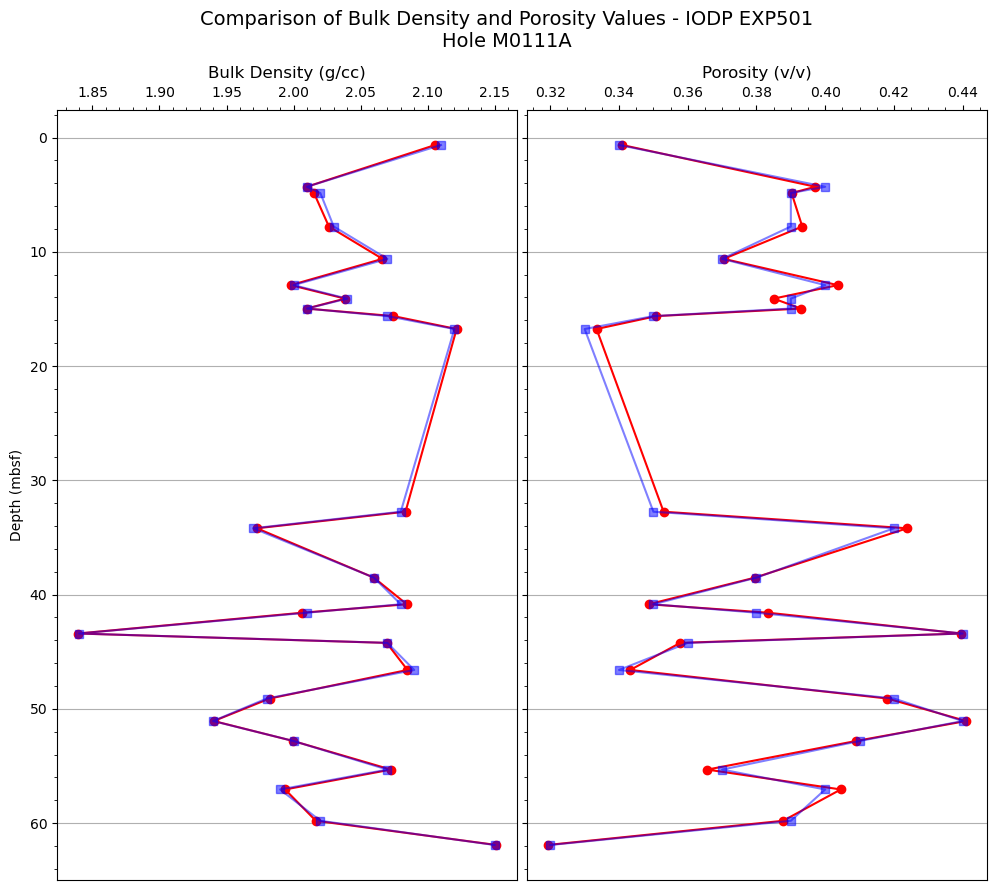

In [171]:
fig, ax = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
fig.subplots_adjust(wspace=0.02)

ax[0].plot(reM0111A_bd, reM0111A_depth, color='red', marker='o')
ax[0].plot(M0111A_bd, M0111A_depth, color='blue', marker='s', alpha=0.5)
ax[0].xaxis.set_label_position('top')
ax[0].xaxis.tick_top()
ax[0].set_title('Bulk Density (g/cc)')
ax[0].minorticks_on()
ax[0].grid(axis='y')
ax[0].set_ylabel('Depth (mbsf)')

ax[1].plot(reM0111A_por, reM0111A_depth, color='red', marker='o')
ax[1].plot(M0111A_por, M0111A_depth, color='blue', marker='s', alpha=0.5)
ax[1].xaxis.set_label_position('top')
ax[1].xaxis.tick_top()
ax[1].set_title('Porosity (v/v)')
ax[1].minorticks_on()
ax[1].grid(axis='y')

plt.gca().invert_yaxis()
fig.suptitle('Comparison of Bulk Density and Porosity Values - IODP EXP501' + '\n' + 'Hole M0111A', fontsize=14)

#### 3.2.2 M0111B ####

In [172]:
M0111B_bd = M0111B['Bulk Density, g/cc']
M0111B_por = M0111B['Porosity,   v/v']
M0111B_depth = M0111B['Sample Bot Depth, mbsf']

reM0111B_bd = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'B'), 'Bulk Density, g/cc']
reM0111B_por = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'B'), 'Porosity, v/v']
reM0111B_depth = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'B'), 'Sample Bot Depth, mbsf']

Text(0.5, 0.98, 'Comparison of Bulk Density and Porosity Values - IODP EXP501, Hole M0111B')

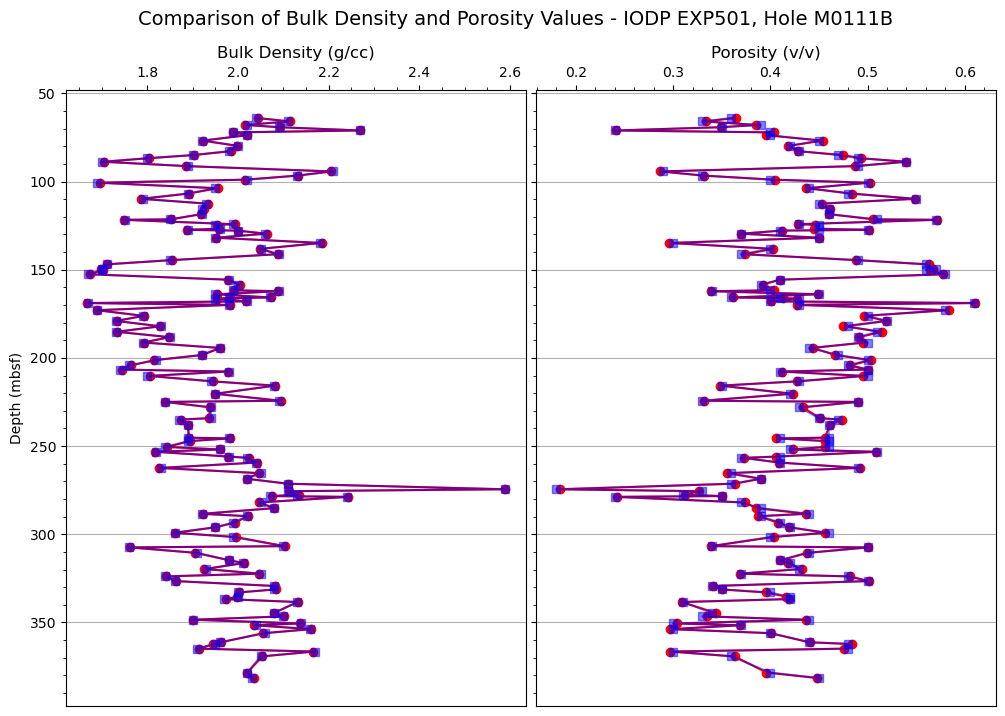

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
fig.subplots_adjust(wspace=0.02)

ax[0].plot(reM0111B_bd, reM0111B_depth, color='red', marker='o')
ax[0].plot(M0111B_bd, M0111B_depth, color='blue', marker='s', alpha=0.5)
ax[0].xaxis.set_label_position('top')
ax[0].xaxis.tick_top()
ax[0].set_title('Bulk Density (g/cc)')
ax[0].minorticks_on()
ax[0].grid(axis='y')
ax[0].set_ylabel('Depth (mbsf)')

ax[1].plot(reM0111B_por, reM0111B_depth, color='red', marker='o')
ax[1].plot(M0111B_por, M0111B_depth, color='blue', marker='s', alpha=0.5)
ax[1].xaxis.set_label_position('top')
ax[1].xaxis.tick_top()
ax[1].set_title('Porosity (v/v)')
ax[1].minorticks_on()
ax[1].grid(axis='y')

plt.gca().invert_yaxis()
fig.suptitle('Comparison of Bulk Density and Porosity Values - IODP EXP501, Hole M0111B', fontsize=14)

#### 3.2.3 M0111C ####

In [174]:
M0111C_bd = M0111C['Bulk Density, g/cc']
M0111C_por = M0111C['Porosity,   v/v']
M0111C_depth = M0111C['Sample Bot Depth, mbsf']

reM0111C_bd = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'C'), 'Bulk Density, g/cc']
reM0111C_por = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'C'), 'Porosity, v/v']
reM0111C_depth = df.loc[(df['Site'] == 'M0111') & (df['Hole'] == 'C'), 'Sample Bot Depth, mbsf']

Text(0.5, 0.98, 'Comparison of Bulk Density and Porosity Values - IODP EXP501, Hole M0111C')

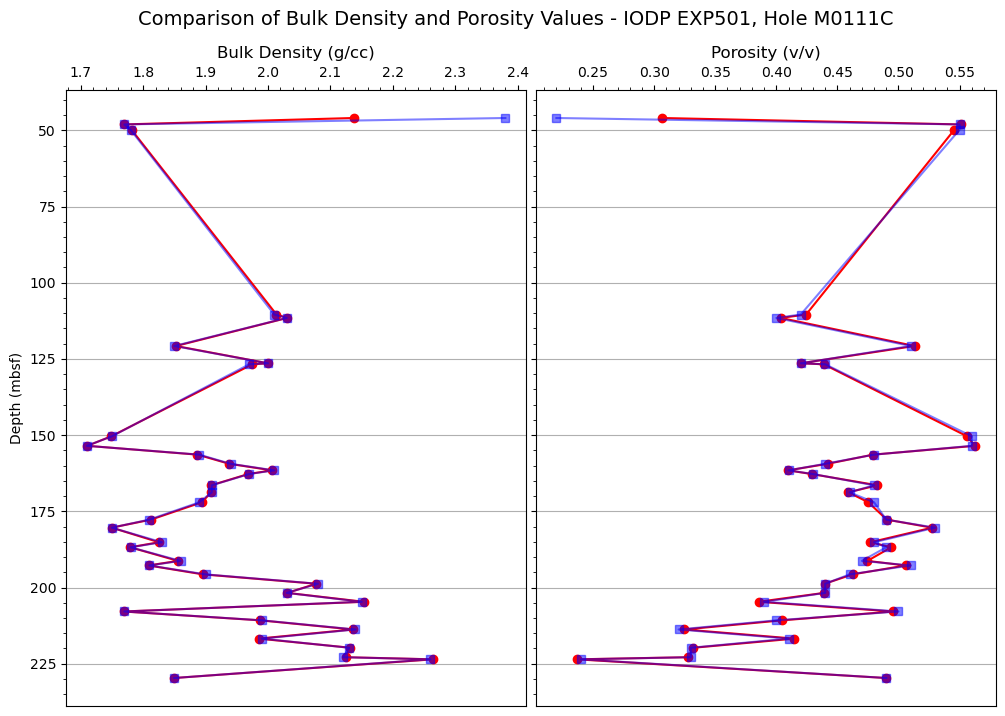

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
fig.subplots_adjust(wspace=0.02)

ax[0].plot(reM0111C_bd, reM0111C_depth, color='red', marker='o')
ax[0].plot(M0111C_bd, M0111C_depth, color='blue', marker='s', alpha=0.5)
ax[0].xaxis.set_label_position('top')
ax[0].xaxis.tick_top()
ax[0].set_title('Bulk Density (g/cc)')
ax[0].minorticks_on()
ax[0].grid(axis='y')
ax[0].set_ylabel('Depth (mbsf)')

ax[1].plot(reM0111C_por, reM0111C_depth, color='red', marker='o')
ax[1].plot(M0111C_por, M0111C_depth, color='blue', marker='s', alpha=0.5)
ax[1].xaxis.set_label_position('top')
ax[1].xaxis.tick_top()
ax[1].set_title('Porosity (v/v)')
ax[1].minorticks_on()
ax[1].grid(axis='y')

plt.gca().invert_yaxis()
fig.suptitle('Comparison of Bulk Density and Porosity Values - IODP EXP501, Hole M0111C', fontsize=14)

#### 3.2.4 M0112A ####

In [176]:
M0112A_bd = M0112A['Bulk Density, g/cc']
M0112A_por = M0112A['Porosity,   v/v']
M0112A_depth = M0112A['Sample Bot Depth, mbsf']

reM0112A_bd = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'A'), 'Bulk Density, g/cc']
reM0112A_por = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'A'), 'Porosity, v/v']
reM0112A_depth = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'A'), 'Sample Bot Depth, mbsf']

Text(0.5, 0.98, 'Comparison of Bulk Density and Porosity Values - IODP EXP501, Hole M0112A')

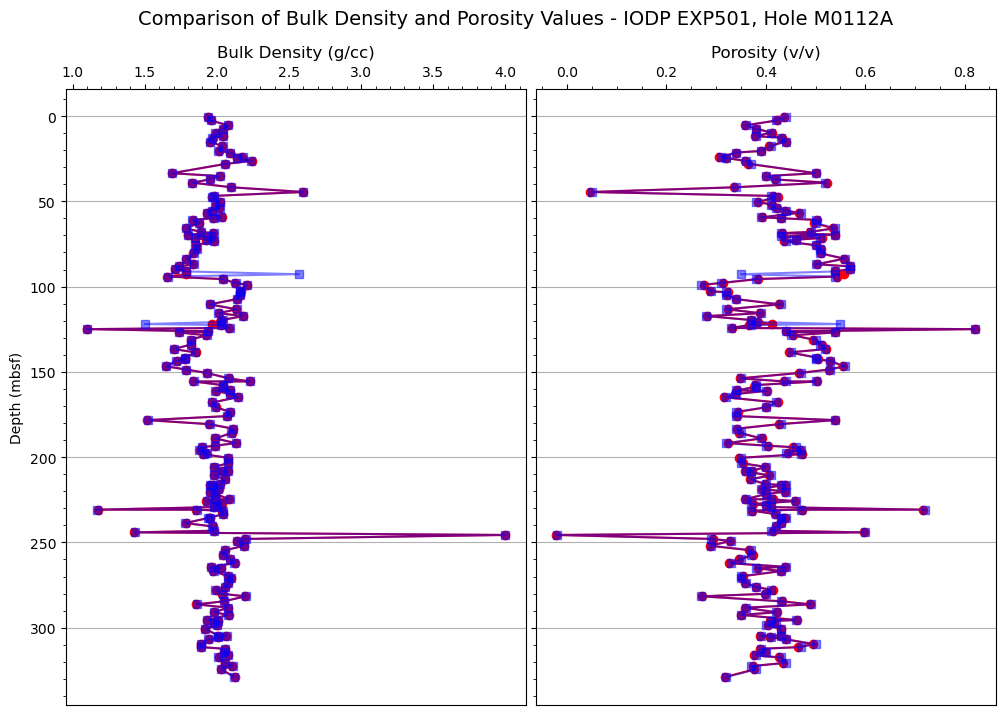

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
fig.subplots_adjust(wspace=0.02)

ax[0].plot(reM0112A_bd, reM0112A_depth, color='red', marker='o')
ax[0].plot(M0112A_bd, M0112A_depth, color='blue', marker='s', alpha=0.5)
ax[0].xaxis.set_label_position('top')
ax[0].xaxis.tick_top()
ax[0].set_title('Bulk Density (g/cc)')
ax[0].minorticks_on()
ax[0].grid(axis='y')
ax[0].set_ylabel('Depth (mbsf)')

ax[1].plot(reM0112A_por, reM0112A_depth, color='red', marker='o')
ax[1].plot(M0112A_por, M0112A_depth, color='blue', marker='s', alpha=0.5)
ax[1].xaxis.set_label_position('top')
ax[1].xaxis.tick_top()
ax[1].set_title('Porosity (v/v)')
ax[1].minorticks_on()
ax[1].grid(axis='y')

plt.gca().invert_yaxis()
fig.suptitle('Comparison of Bulk Density and Porosity Values - IODP EXP501, Hole M0112A', fontsize=14)

#### 3.2.5 M0112B ####

In [178]:
M0112B_bd = M0112B['Bulk Density, g/cc']
M0112B_por = M0112B['Porosity,   v/v']
M0112B_depth = M0112B['Sample Bot Depth, mbsf']

reM0112B_bd = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'B'), 'Bulk Density, g/cc']
reM0112B_por = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'B'), 'Porosity, v/v']
reM0112B_depth = df.loc[(df['Site'] == 'M0112') & (df['Hole'] == 'B'), 'Sample Bot Depth, mbsf']

Text(0.5, 0.98, 'Comparison of Bulk Density and Porosity Values - IODP EXP501, Hole M0112A')

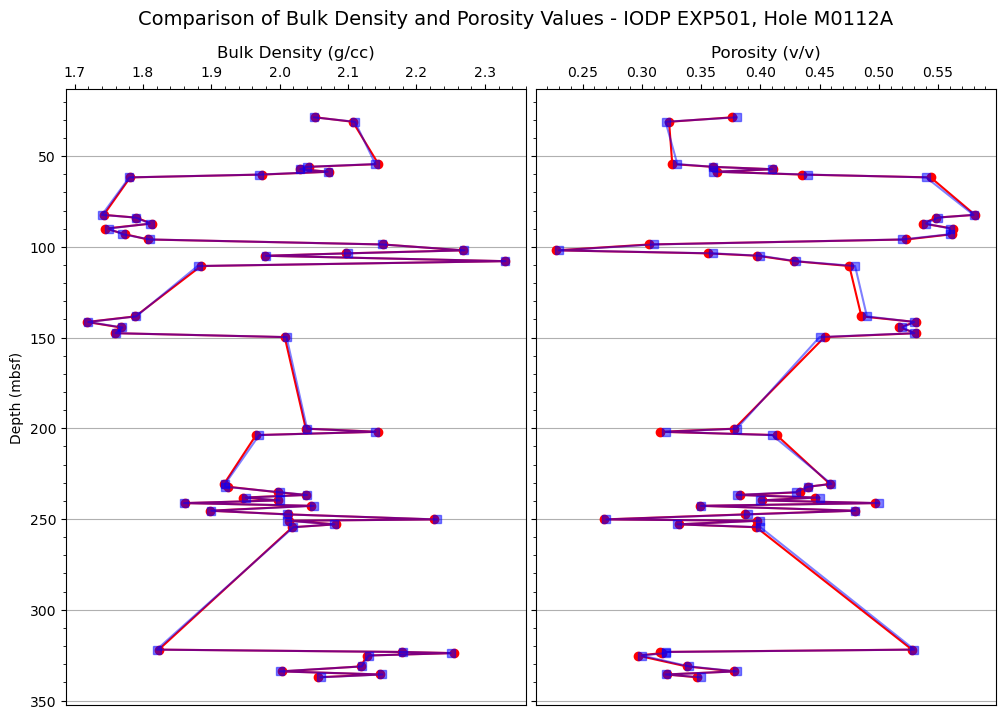

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
fig.subplots_adjust(wspace=0.02)

ax[0].plot(reM0112B_bd, reM0112B_depth, color='red', marker='o')
ax[0].plot(M0112B_bd, M0112B_depth, color='blue', marker='s', alpha=0.5)
ax[0].xaxis.set_label_position('top')
ax[0].xaxis.tick_top()
ax[0].set_title('Bulk Density (g/cc)')
ax[0].minorticks_on()
ax[0].grid(axis='y')
ax[0].set_ylabel('Depth (mbsf)')

ax[1].plot(reM0112B_por, reM0112B_depth, color='red', marker='o')
ax[1].plot(M0112B_por, M0112B_depth, color='blue', marker='s', alpha=0.5)
ax[1].xaxis.set_label_position('top')
ax[1].xaxis.tick_top()
ax[1].set_title('Porosity (v/v)')
ax[1].minorticks_on()
ax[1].grid(axis='y')

plt.gca().invert_yaxis()
fig.suptitle('Comparison of Bulk Density and Porosity Values - IODP EXP501, Hole M0112A', fontsize=14)

#### 3.2.6 M0113A ####

In [180]:
M0113A_bd = M0113A['Bulk Density, g/cc']
M0113A_por = M0113A['Porosity,   v/v']
M0113A_depth = M0113A['Sample Bot Depth, mbsf']

reM0113A_bd = df.loc[(df['Site'] == 'M0113') & (df['Hole'] == 'A'), 'Bulk Density, g/cc']
reM0113A_por = df.loc[(df['Site'] == 'M0113') & (df['Hole'] == 'A'), 'Porosity, v/v']
reM0113A_depth = df.loc[(df['Site'] == 'M0113') & (df['Hole'] == 'A'), 'Sample Bot Depth, mbsf']

Text(0.5, 0.98, 'Comparison of Bulk Density and Porosity Values - IODP EXP501, Hole M0112A')

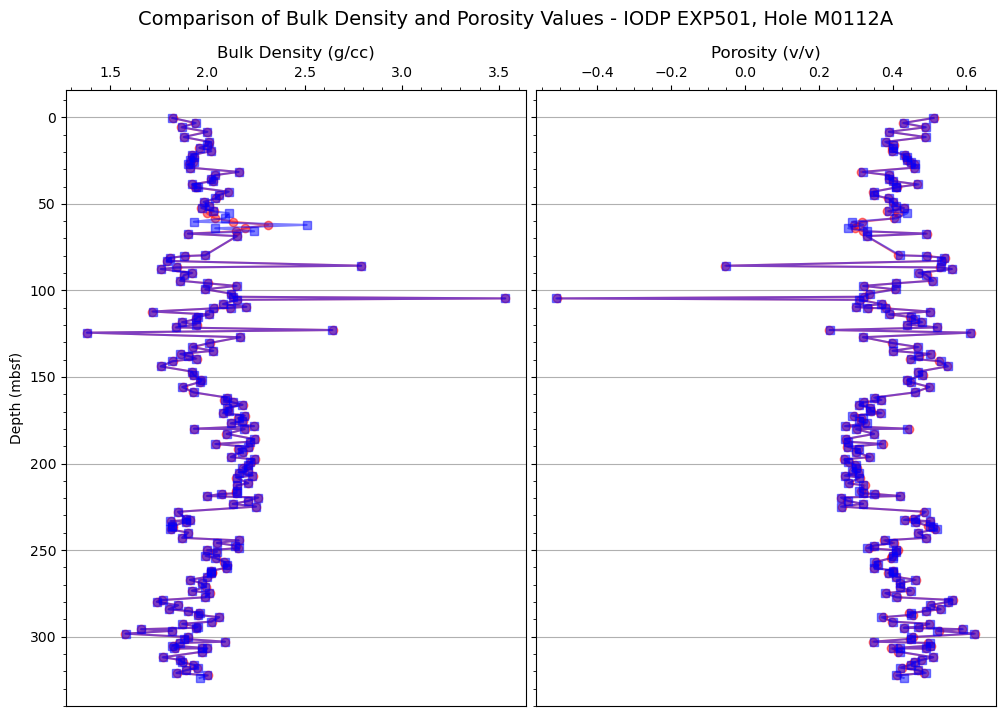

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
fig.subplots_adjust(wspace=0.02)

ax[0].plot(reM0113A_bd, reM0113A_depth, color='red', marker='o', alpha=0.5)
ax[0].plot(M0113A_bd, M0113A_depth, color='blue', marker='s', alpha=0.5)
ax[0].xaxis.set_label_position('top')
ax[0].xaxis.tick_top()
ax[0].set_title('Bulk Density (g/cc)')
ax[0].minorticks_on()
ax[0].grid(axis='y')
ax[0].set_ylabel('Depth (mbsf)')

ax[1].plot(reM0113A_por, reM0113A_depth, color='red', marker='o', alpha=0.5)
ax[1].plot(M0113A_por, M0113A_depth, color='blue', marker='s', alpha=0.5)
ax[1].xaxis.set_label_position('top')
ax[1].xaxis.tick_top()
ax[1].set_title('Porosity (v/v)')
ax[1].minorticks_on()
ax[1].grid(axis='y')

plt.gca().invert_yaxis()
fig.suptitle('Comparison of Bulk Density and Porosity Values - IODP EXP501, Hole M0112A', fontsize=14)